# Figure 9 — Injection truth test (astrometry)

Synthetic point sources injected at KNOWN sub-pixel positions into all 10 bands of
held-out patch-25 tiles; median position error vs the injected truth as a function of S/N,
for the Rubin bands (where the head transfers VIS localization to the ground-based data).
Immune to the centroid-emulation degeneracy of label-based residuals.

In [1]:
from pathlib import Path
import numpy as np, json
def find_repo_root(s=None):
    s=(s or Path.cwd()).resolve()
    for c in [s,*s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError
REPO=find_repo_root(); OUT=REPO/'paper'/'figures'/'fig9_injection_truth.png'
inj=json.load(open(REPO/'io/_nb09_outputs/injection_truth_results.json'))['records']
jt =json.load(open(REPO/'io/_nb09_outputs/joint_centroid_truth_results.json'))
SNRS=[5,7,10,15,30]
def med_rubin(key):
    return [1000*np.median([r[key] for r in inj if r['snr']==s and r['band'].startswith('rubin')]) for s in SNRS]
def med_joint():
    return [1000*np.median([r['err_joint'] for r in jt if r['snr']==s]) for s in SNRS]
curves={
 'classical single-band': med_rubin('err_band'),
 'VIS-localization floor': med_rubin('err_vis'),
 'head (VIS labels)':      med_rubin('err_head_patchval'),
 'head (joint labels)':    med_rubin('err_head_joint'),
}
for k,v in curves.items(): print(f"{k:30s}", [f'{x:.1f}' for x in v])


classical single-band          ['47.6', '34.1', '24.1', '15.9', '8.0']
VIS-localization floor         ['17.5', '13.1', '9.0', '5.7', '2.9']
head (VIS labels)              ['19.6', '13.3', '9.3', '7.0', '5.9']
head (joint labels)            ['19.3', '14.0', '10.0', '6.6', '4.0']


saved paper/figures/fig9_injection_truth.png


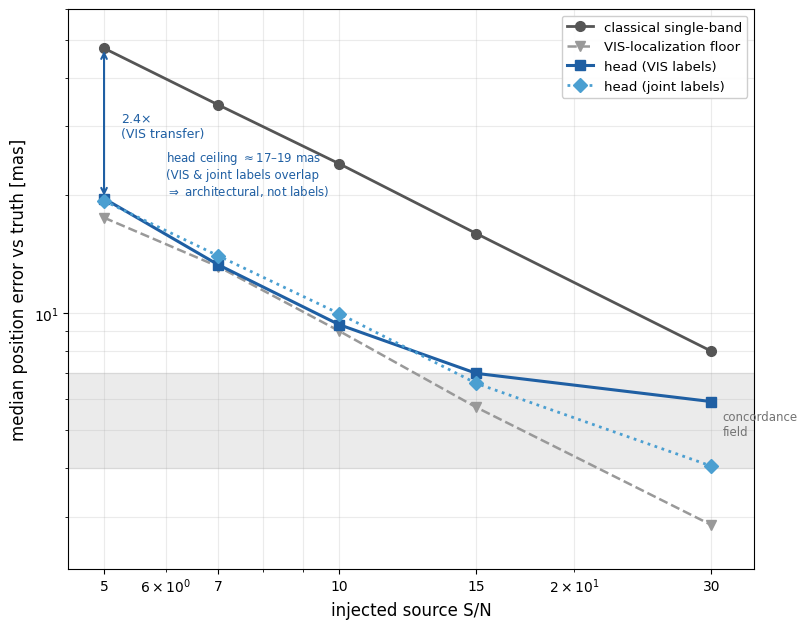

In [2]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(8.2,6.4))
S=np.array(SNRS)
style={
 'classical single-band':      dict(color='#555555',marker='o',ls='-',lw=2),
 'VIS-localization floor':     dict(color='#999999',marker='v',ls='--',lw=1.8),
 'head (VIS labels)':          dict(color='#1f5fa3',marker='s',ls='-',lw=2.2),
 'head (joint labels)':        dict(color='#4b9fd1',marker='D',ls=':',lw=2.0),
}
# concordance field scale band
ax.axhspan(4,7,color='0.85',alpha=0.5,zorder=0)
ax.text(31,5.2,'concordance\nfield',fontsize=8.5,color='0.45',va='center',ha='left')
for k,v in curves.items():
    st=dict(style[k]); st.setdefault('ms',7)
    ax.plot(S,v,label=k,**st)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xticks(SNRS); ax.set_xticklabels(SNRS)
ax.set_xlabel('injected source S/N',fontsize=12); ax.set_ylabel('median position error vs truth [mas]',fontsize=12)
ax.grid(True,which='both',alpha=0.25)
# annotations
ax.annotate('',xy=(5,curves['head (VIS labels)'][0]),xytext=(5,curves['classical single-band'][0]),
            arrowprops=dict(arrowstyle='<->',color='#1f5fa3',lw=1.5))
ax.text(5.25,30,'2.4$\\times$\n(VIS transfer)',color='#1f5fa3',fontsize=9,va='center')
ax.text(6,20,'head ceiling $\\approx$17–19 mas\n(VIS & joint labels overlap\n$\\Rightarrow$ architectural, not labels)',fontsize=8.5,color='#1f5fa3')
ax.legend(fontsize=9.5,loc='upper right',framealpha=0.95)
ax.set_xlim(4.5,34); ax.set_ylim(2.2,60)
plt.tight_layout(); OUT.parent.mkdir(parents=True,exist_ok=True)
fig.savefig(OUT,dpi=200,bbox_inches='tight'); print('saved',OUT.relative_to(REPO)); plt.show()
